In [1]:
import sys
import os
import pandas as pd
import numpy as np
import pickle
import joblib
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from scipy.stats import norm

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

from MODELS.xgboostModel import *
from MODELS.ngboostModel import *
from ngboost.distns import Normal

# Try to import NegativeBinomial, fall back to Normal if not available
try:
    from ngboost.distns import NegativeBinomial
except ImportError:
    print("Warning: NegativeBinomial not available in this NGBOOST version. Using Normal distribution.")
    print("Note: You can still use Negative Binomial for probability calculations.")
    NegativeBinomial = Normal  # Use Normal as fallback

Note: You can still use Negative Binomial for probability calculations.


/Users/alexgonzalez/Documents/NBA-Prop-Predictor/nba_model/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pd.set_option('display.max_columns', None)

s22 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_22.csv')
s23 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_23.csv')
s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')

train_df = pd.concat([s22,s23,s24,s25])
val_df = s26
# test_df = s26

print("BEFORE FILTERING:")
print(f"Train set: {len(train_df)} samples")
print(f"Val set: {len(val_df)} samples")
train_df.sample()

BEFORE FILTERING:
Train set: 104668 samples
Val set: 6767 samples


,Unnamed: 0,PLAYER_NAME,PLAYER_ID,MATCHUP,TEAM_ABBREVIATION,TEAM_ID,OPP_ABBREVIATION,HOME_GAME,GAME_ID,GAME_DATE,WL,PTS,AST,REB,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,STL,BLK,TOV,PLUS_MINUS,FANTASY_PTS,POINT_PER_SHOT,EFG,START_POSITION,COMMENT,E_OFF_RATING,E_DEF_RATING,NET_RATING,OREB_PCT,DREB_PCT,REB_PCT,AST_PCT,EFG_PCT,AST_TOV,USG_PCT,TS_PCT,E_PACE,PACE,PIE,POSS,PACE_PER40,E_USG_PCT,MIN,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,PTS_OFF_TOV,PTS_2ND_CHANCE,PTS_FB,PTS_PAINT,OPP_PTS_OFF_TOV,OPP_PTS_2ND_CHANCE,OPP_PTS_FB,OPP_PTS_PAINT,BLKA,PF,PFD,IS_PLAYOFF,TEAM_SEASON_ID_x,whos_favored,spread,total,team_is_favored,team_spread,OPP_BLOWOUT_RISK,TEAM_NAME,TEAM_MIN,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_STL,TEAM_BLK,TEAM_TOV,TEAM_PF,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_PACE,GAME_PACE,OPP_PACE,OPP_TEAM_ID,TEAM_OFF_RATING,TEAM_DEF_RATING,OPP_DEF_RATING,OPP_OFF_RATING,OPP_PTS,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_REB,OPP_AST,OPP_STL,OPP_BLK,OPP_TOV,percentageFieldGoalsAttempted2pt,percentageFieldGoalsAttempted3pt,percentagePoints2pt,percentagePointsMidrange2pt,percentagePoints3pt,percentagePointsFastBreak,percentagePointsFreeThrow,percentagePointsOffTurnovers,percentagePointsPaint,percentageAssisted2pt,percentageUnassisted2pt,percentageAssisted3pt,percentageUnassisted3pt,percentageAssistedFGM,percentageUnassistedFGM,matchupFieldGoalsMade,matchupFieldGoalsAttempted,matchupThreePointersMade,matchupThreePointersAttempted,playerPoints,matchupMinutes,GP,AGE,FREQ_FG3,FG3M_main,FG3A_main,FG3_PCT_main,NS_FG3_PCT,PLUS_MINUS_FG3,FREQ_FG2,FG2M,FG2A,FG2_PCT,NS_FG2_PCT,PLUS_MINUS_FG2,FREQ_LT_06,FGM_LT_06,FGA_LT_06,LT_06_PCT,NS_LT_06_PCT,PLUS_MINUS_LT_06,FREQ_LT_10,FGM_LT_10,FGA_LT_10,LT_10_PCT,NS_LT_10_PCT,PLUS_MINUS_LT_10,FREQ_GT_15,FGM_GT_15,FGA_GT_15,GT_15_PCT,NS_GT_15_PCT,PLUS_MINUS_GT_15,STARTING,HEIGHT,WEIGHT,GUARD,FORWARD,CENTER,TEAM_DAYS_REST,PLAYER_DAYS_REST,TEAM_B2B,IS_BACK_TO_BACK,PLAYER_MISSED_LAST,PTS_ROLLING_AVG_3,FGA_ROLLING_AVG_3,FGM_ROLLING_AVG_3,FG3A_ROLLING_AVG_3,FG3M_ROLLING_AVG_3,FTA_ROLLING_AVG_3,FTM_ROLLING_AVG_3,UFGA_ROLLING_AVG_3,UFGM_ROLLING_AVG_3,CFGA_ROLLING_AVG_3,CFGM_ROLLING_AVG_3,USG_PCT_ROLLING_AVG_3,MIN_ROLLING_AVG_3,POSS_ROLLING_AVG_3,PLUS_MINUS_ROLLING_AVG_3,TS_PCT_ROLLING_AVG_3,SPD_ROLLING_AVG_3,PF_ROLLING_AVG_3,PASS_ROLLING_AVG_3,SAST_ROLLING_AVG_3,AST_ROLLING_AVG_3,REB_ROLLING_AVG_3,OREB_ROLLING_AVG_3,DREB_ROLLING_AVG_3,TOV_ROLLING_AVG_3,E_OFF_RATING_ROLLING_AVG_3,NET_RATING_ROLLING_AVG_3,EFG_PCT_ROLLING_AVG_3,TCHS_ROLLING_AVG_3,FG_PCT_ROLLING_AVG_3,FG3_PCT_ROLLING_AVG_3,FT_PCT_ROLLING_AVG_3,PTS_OFF_TOV_ROLLING_AVG_3,PTS_2ND_CHANCE_ROLLING_AVG_3,PTS_FB_ROLLING_AVG_3,PTS_PAINT_ROLLING_AVG_3,PTS_ROLLING_AVG_5,FGA_ROLLING_AVG_5,FGM_ROLLING_AVG_5,FG3A_ROLLING_AVG_5,FG3M_ROLLING_AVG_5,FTA_ROLLING_AVG_5,FTM_ROLLING_AVG_5,UFGA_ROLLING_AVG_5,UFGM_ROLLING_AVG_5,CFGA_ROLLING_AVG_5,CFGM_ROLLING_AVG_5,USG_PCT_ROLLING_AVG_5,MIN_ROLLING_AVG_5,POSS_ROLLING_AVG_5,PLUS_MINUS_ROLLING_AVG_5,TS_PCT_ROLLING_AVG_5,SPD_ROLLING_AVG_5,PF_ROLLING_AVG_5,PASS_ROLLING_AVG_5,SAST_ROLLING_AVG_5,AST_ROLLING_AVG_5,REB_ROLLING_AVG_5,OREB_ROLLING_AVG_5,DREB_ROLLING_AVG_5,TOV_ROLLING_AVG_5,E_OFF_RATING_ROLLING_AVG_5,NET_RATING_ROLLING_AVG_5,EFG_PCT_ROLLING_AVG_5,TCHS_ROLLING_AVG_5,FG_PCT_ROLLING_AVG_5,FG3_PCT_ROLLING_AVG_5,FT_PCT_ROLLING_AVG_5,PTS_OFF_TOV_ROLLING_AVG_5,PTS_2ND_CHANCE_ROLLING_AVG_5,PTS_FB_ROLLING_AVG_5,PTS_PAINT_ROLLING_AVG_5,PTS_ROLLING_AVG_7,FGA_ROLLING_AVG_7,FGM_ROLLING_AVG_7,FG3A_ROLLING_AVG_7,FG3M_ROLLING_AVG_7,FTA_ROLLING_AVG_7,FTM_ROLLING_AVG_7,UFGA_ROLLING_AVG_7,UFGM_ROLLING_AVG_7,CFGA_ROLLING_AVG_7,CFGM_ROLLING_AVG_7,USG_PCT_ROLLING_AVG_7,MIN_ROLLING_AVG_7,POSS_ROLLING_AVG_7,PLUS_MINUS_ROLLING_AVG_7,TS_PCT_ROLLING_AVG_7,SPD_ROLLING_AVG_7,PF_ROLLING_AVG_7,PASS_ROLLING_AVG_7,SAST_ROLLING_AVG_7,AST_ROLLING_AVG_7,REB_ROLLING_AVG_7,OREB_ROLLING_AVG_7,DREB_ROLLING_AVG_7,TO

In [3]:
player_season_avg = train_df.groupby('PLAYER_ID').agg({
    'MIN': 'mean',
    'PTS': 'mean',
    'GAMES_PLAYED_TO_DATE': 'max'
}).reset_index()

player_season_avg.columns = ['PLAYER_ID', 'MIN_AVG', 'PTS_AVG', 'GAMES_PLAYED']

# Define criteria for "relevant players"
relevant_players = player_season_avg[
    (player_season_avg['MIN_AVG'] >= 12) &      
    (player_season_avg['GAMES_PLAYED'] >= 8)
]['PLAYER_ID']

# Filter training data to only relevant players
train_df = train_df[train_df['PLAYER_ID'].isin(relevant_players)]
train_df = train_df[
    (train_df['PTS'] <= 50) &  
    (train_df['MIN'] >= 8) &
    (train_df['MIN'] <= 48) &
    (train_df['USG_PCT'] <= 0.4)    
]
train_df = train_df.dropna(subset=['PTS_ROLLING_AVG_3'])

val_df = val_df[val_df['PLAYER_ID'].isin(relevant_players)]
val_df = val_df[
    (val_df['PTS'] <= 50) &  
    (val_df['MIN'] >= 8) &
    (val_df['MIN'] <= 48) &
    (val_df['USG_PCT'] <= 0.4)    
]
val_df = val_df.dropna(subset=['PTS_ROLLING_AVG_3'])

# test_df = test_df[test_df['PLAYER_ID'].isin(relevant_players)]
# test_df = test_df[
#     (test_df['PTS'] <= 45) &  
#     (test_df['MIN'] >= 8) &
#     (test_df['MIN'] <= 40) &
#     (test_df['USG_PCT'] <= 0.4)    
# ]
# test_df = test_df.dropna(subset=['PTS_ROLLING_AVG_3'])

print("AFTER FILTERING:")
print(f"Train set: {len(train_df)} samples")
print(f"Val set: {len(val_df)} samples")
# print(f"Test set: {len(test_df)} samples")

AFTER FILTERING:
Train set: 85061 samples
Val set: 4646 samples


In [4]:
USG_features = [
    # Player context
    'PLAYER_IS_TEAM_STAR',
    'STAR_SAT_OUT',
    'LINEUP_FGA_SHARE_AVG', 
    'USG_PCT_AVG_TO_DATE', 
    'USG_PCT_L5_OVER_BASELINE',
    'USG_PER_MIN',

    #new
    'PASSES_PER_TOUCHES',
    'PASS_AVG_TO_DATE',
    'SAST_AVG_TO_DATE',
    'TCHS_AVG_TO_DATE',
    
]
USG_target = 'USG_PCT'
print(f"len(USG_features): {len(USG_features)}")
"""
# ADD THESE:
ON_OFF_STAR_PG
ON_OFF_PRIMARY_SCORER
ON_OFF_SECOND_CREATOR
LINEUP_USG_SHARE_AVG
LINEUP_FGA_SHARE_AVG
EXPECTED_TOUCHES
PRIMARY_HANDLER_RATE
MATCHUP_DOUBLE_TEAM_RATE
MATCHUP_PNR_COVERAGE
"""

len(USG_features): 10


'\n# ADD THESE:\nON_OFF_STAR_PG\nON_OFF_PRIMARY_SCORER\nON_OFF_SECOND_CREATOR\nLINEUP_USG_SHARE_AVG\nLINEUP_FGA_SHARE_AVG\nEXPECTED_TOUCHES\nPRIMARY_HANDLER_RATE\nMATCHUP_DOUBLE_TEAM_RATE\nMATCHUP_PNR_COVERAGE\n'

In [5]:
MIN_features = [
    # Player info
    'STARTING',
    'STAR_SAT_OUT', #new
    'PLAYER_DAYS_REST',
    'USUAL_STARTERS_AVAILABLE',
    'MIN_CEILING_L5_DELTA',
    'MIN_FLOOR_L5_DELTA',
    'STARTING_x_MIN_AVG',
    'STARTING_x_MIN_CEILING',

    # Baseline minute distribution
    'MIN_AVG_TO_DATE',
    'MIN_L5_OVER_BASELINE',
    'MIN_L7_OVER_BASELINE',
    'MIN_L10_OVER_BASELINE',
    'MIN_STD_5_TO_DATE',
    'MIN_STD_10_TO_DATE',
    'MIN_BOOST_STAR_OUT',

    'SPD_L5_OVER_BASELINE', #new
    'SPD_L10_OVER_BASELINE', #new

    # Matchup & location expectational
    'MIN_EXPECTATION_LOCATION',
    'MATCHUP_MIN_DELTA',

    # Team context – keep only strongest predictors
    'TEAM_PACE_OVER_LEAGUE_AVG',
    'EXPECTED_PACE',

    # Opponent effects
    'OPP_DEF_RATING_OVER_LEAGUE_AVG',
    'OPP_PACE_OVER_LEAGUE_AVG',
]
MIN_target = 'MIN'
print(f"len(MIN_features): {len(MIN_features)}")
"""
# ADD:
AVAILABLE_GUARDS
AVAILABLE_WINGS
AVAILABLE_BIGS
OUT_SAME_POSITION_COUNT     # massive improvement

TEAM_ROTATION_STD
COACH_ROTATION_TIGHTNESS

SPREAD                      # blowout indicator
BLOWOUT_RISK
TRAVEL_DISTANCE_LAST_3_DAYS
REST_DAYS_TEAM_AVG
"""

len(MIN_features): 23


'\n# ADD:\nAVAILABLE_GUARDS\nAVAILABLE_WINGS\nAVAILABLE_BIGS\nOUT_SAME_POSITION_COUNT     # massive improvement\n\nTEAM_ROTATION_STD\nCOACH_ROTATION_TIGHTNESS\n\nSPREAD                      # blowout indicator\nBLOWOUT_RISK\nTRAVEL_DISTANCE_LAST_3_DAYS\nREST_DAYS_TEAM_AVG\n'

In [6]:
# Train cascading model: MIN -> USG_PCT -> PTS
cascading_models = train_cascading_model(
    train_data=train_df,
    val_data=val_df,
    min_features=MIN_features,
    usg_features=USG_features,
    date_column='GAME_DATE',
    player_column='PLAYER_ID'
)

# Extract models and metrics
min_model = cascading_models['min_model']
usg_model = cascading_models['usg_model']
# pts_model = cascading_models['pts_model']
metrics = cascading_models['metrics']

print("\n" + "="*70)
print("CASCADING MODEL SUMMARY")
print("="*70)
print(f"\nMIN Model - R²: {metrics['MIN']['R2']:.3f}, RMSE: {metrics['MIN']['RMSE']:.3f}")
print(f"USG_PCT Model - R²: {metrics['USG_PCT']['R2']:.3f}, RMSE: {metrics['USG_PCT']['RMSE']:.3f}")



TRAINING CASCADING MODEL: MIN -> USG_PCT
(PTS will use Negative Binomial model separately)

STEP 1: Training MIN Model

TRAINING XGBOOST MODEL

📅 Step 1: Sorting by date...
   Training: 2021-10-21 to 2025-04-13
   Validation: 2025-10-23 to 2025-12-01

🧹 Step 2: Removing rows with missing target...
   Training samples: 85061
   Validation samples: 4646

📊 Step 3: Preparing features...

🔧 Step 4: Handling NaN values in features...
   • Filled 11314 NaN in training features
   • Filled 2141 NaN in validation features
   • Remaining NaN: 0

⚖️  Step 5: Creating sample weights...
   ✓ Applied 3x weight to last 15 games per player

🤖 Step 6: Training XGBoost...
   ✓ Training stopped at iteration 648

📈 Step 7: Evaluating on validation...

   VALIDATION METRICS:
   • RMSE: 5.226
   • MAE:  4.050
   • R²:   0.595

   Predictions: min=13.82, max=36.79, mean=25.67
   Actual:      min=8.05, max=47.43, mean=25.64

🔄 Step 8: Retraining on combined data...
   ✓ Final model trained on 89707 games

✅

In [7]:
# Prepare training data with predicted MIN and USG
# We need to add predicted MIN and USG to our datasets

def add_predicted_min_usg(df, min_model, usg_model, min_features, usg_features):
    """Add predicted MIN and USG_PCT to dataframe using trained models"""
    df = df.copy()
    
    # Predict MIN first
    X_min = df[min_features].fillna(0)
    df['PREDICTED_MIN'] = min_model.predict(X_min)
    
    # Predict USG using predicted MIN
    X_usg = df[usg_features].copy()
    X_usg['PREDICTED_MIN'] = df['PREDICTED_MIN']
    X_usg = X_usg.fillna(0)
    df['PREDICTED_USG_PCT'] = usg_model.predict(X_usg)
    
    return df

# Add predictions to train and val sets
print("\n📊 Step 1: Adding predicted MIN and USG to datasets...")
train_df_with_preds = add_predicted_min_usg(train_df, min_model, usg_model, MIN_features, USG_features)
val_df_with_preds = add_predicted_min_usg(val_df, min_model, usg_model, MIN_features, USG_features)

print(f"   Training samples: {len(train_df_with_preds)}")
print(f"   Validation samples: {len(val_df_with_preds)}")
print(f"   PREDICTED_MIN range: {train_df_with_preds['PREDICTED_MIN'].min():.1f} - {train_df_with_preds['PREDICTED_MIN'].max():.1f}")
print(f"   PREDICTED_USG_PCT range: {train_df_with_preds['PREDICTED_USG_PCT'].min():.3f} - {train_df_with_preds['PREDICTED_USG_PCT'].max():.3f}")



📊 Step 1: Adding predicted MIN and USG to datasets...
   Training samples: 85061
   Validation samples: 4646
   PREDICTED_MIN range: 9.1 - 46.1
   PREDICTED_USG_PCT range: 0.115 - 0.301



SHAP ANALYSIS:
   Model expects: 11 features
   Test data has: 11 features
------------------------------
Top 15 Features by SHAP importance:
  USG_PCT_AVG_TO_DATE            0.0333
  LINEUP_FGA_SHARE_AVG           0.0035
  TCHS_AVG_TO_DATE               0.0031
  PREDICTED_MIN                  0.0029
  USG_PCT_L5_OVER_BASELINE       0.0019
  PASSES_PER_TOUCHES             0.0015
  USG_PER_MIN                    0.0009
  PLAYER_IS_TEAM_STAR            0.0007
  PASS_AVG_TO_DATE               0.0006
  STAR_SAT_OUT                   0.0005
  SAST_AVG_TO_DATE               0.0000


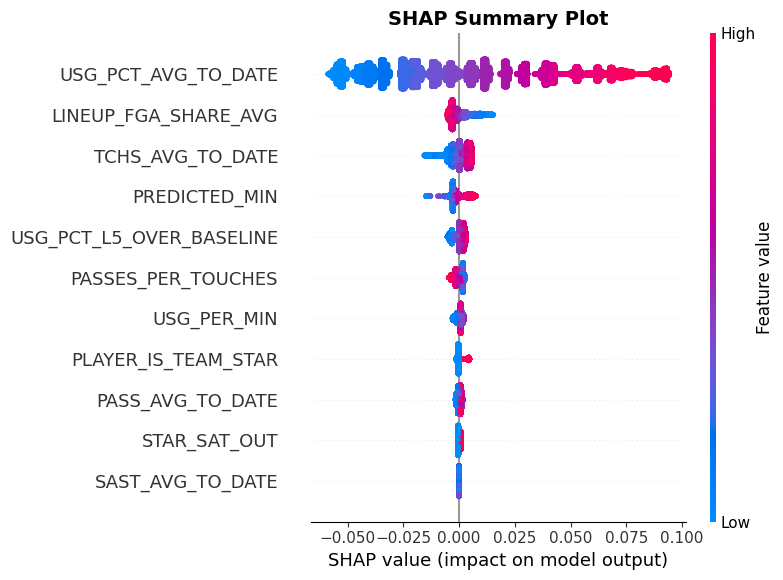

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.75
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [8]:
analyze_shap(usg_model, train_df_with_preds, USG_features, 'USG_PCT')

In [18]:
# PTS Features for NGBOOST
PTS_features = [
    'STARTING',
    'GAMES_PLAYED_TO_DATE',
    'PTS_CEILING_L5_DELTA',
    'PTS_FLOOR_L5_DELTA', 

    # Predicted upstream values (most important)
    'PREDICTED_MIN',
    'PREDICTED_USG_PCT',
    'PREDICTED_MIN_x_PREDICTED_USG_PCT', 
    
    # Baseline stats
    'PTS_AVG_TO_DATE',
    'PTS_STD_5_TO_DATE',
    'PTS_BOOST_STAR_OUT', 
    'PTS_EXPECTATION_LOCATION', 
    
    'PTS_2ND_CHANCE_L5_OVER_BASELINE', 
    'PTS_2ND_CHANCE_L10_OVER_BASELINE', 
    'PTS_FB_L5_OVER_BASELINE', 
    'PTS_FB_L10_OVER_BASELINE',
    'PTS_PAINT_L5_OVER_BASELINE', 
    'PTS_PAINT_L10_OVER_BASELINE', 

    'CFGA_AVG_TO_DATE', #new

    'UFGA_AVG_TO_DATE', #new
    'UFGA_L5_OVER_BASELINE', #new

    'FGA_AVG_TO_DATE',
    'FGA_BOOST_STAR_OUT', 
    'FGA_EXPECTATION_LOCATION', 

    'FTA_AVG_TO_DATE',
    'FTA_L5_OVER_BASELINE',
    'FTA_L10_OVER_BASELINE',
    'FTA_BOOST_STAR_OUT', 
    'FTA_EXPECTATION_LOCATION',

    'FG3A_AVG_TO_DATE',
    'FG3A_L5_OVER_BASELINE',
    'FG3A_L10_OVER_BASELINE',
    'FG3A_BOOST_STAR_OUT', 
    'FG3A_EXPECTATION_LOCATION', 
    
    'PLUS_MINUS_AVG_TO_DATE',
    'PLUS_MINUS_L5_OVER_BASELINE',
    'PLUS_MINUS_L10_OVER_BASELINE',
    'PLUS_MINUS_BOOST_STAR_OUT', 
    'PLUS_MINUS_EXPECTATION_LOCATION', 
    
    'FG_PCT_AVG_TO_DATE',
    'FG_PCT_L5_OVER_BASELINE',
    'FG_PCT_EXPECTATION_LOCATION',
    'MATCHUP_FG_PCT_DELTA', 

    'FG3_PCT_AVG_TO_DATE',
    'MATCHUP_FG3_PCT_DELTA', 

    'FT_PCT_AVG_TO_DATE',
    'FT_PCT_L5_OVER_BASELINE',
    'FT_PCT_L10_OVER_BASELINE',
    'FT_PCT_BOOST_STAR_OUT',
    'FT_PCT_EXPECTATION_LOCATION', 

    'TS_PCT_AVG_TO_DATE',
    'TS_PCT_L5_OVER_BASELINE',
    'TS_PCT_L10_OVER_BASELINE',
    'TS_PCT_BOOST_STAR_OUT', 
    'TS_PCT_EXPECTATION_LOCATION', 
    'MATCHUP_TS_PCT_DELTA', 
    
    # VARIANCE STABILITY
    'PTS_VARIANCE_STABILITY',
    'FGA_VARIANCE_STABILITY',
    'FTA_VARIANCE_STABILITY',
    'FG3A_VARIANCE_STABILITY',
    'TS_PCT_VARIANCE_STABILITY',

    # Team/Opponent context
    'TEAM_OFF_RATING_OVER_LEAGUE_AVG',
    'TEAM_PACE_OVER_LEAGUE_AVG',
    'EXPECTED_PACE',
    'OPP_PACE_OVER_LEAGUE_AVG',
    
    # Positional defense
    'GUARD_DEF_RATING_OVER_LEAGUE_AVG',
    'FORWARD_DEF_RATING_OVER_LEAGUE_AVG',
]

# Create interaction term
train_df_with_preds['PREDICTED_MIN_x_PREDICTED_USG_PCT'] = (
    train_df_with_preds['PREDICTED_MIN'] * train_df_with_preds['PREDICTED_USG_PCT']
)
val_df_with_preds['PREDICTED_MIN_x_PREDICTED_USG_PCT'] = (
    val_df_with_preds['PREDICTED_MIN'] * val_df_with_preds['PREDICTED_USG_PCT']
)

# Filter to only rows where we have all features
# Include PLAYER_ID for sample weights (not in features list)
train_df_pts = train_df_with_preds[['PTS', 'PLAYER_ID'] + PTS_features].copy()
val_df_pts = val_df_with_preds[['PTS', 'PLAYER_ID'] + PTS_features].copy()

# Note: NGBOOST handles NaN values internally, no need to fill here
print(f"\n📊 Step 2: Preparing feature matrices...")
print(f"   Training samples: {len(train_df_pts)}")
print(f"   Validation samples: {len(val_df_pts)}")
print(f"   Features: {len(PTS_features)}")
print(f"   Points range: {train_df_pts['PTS'].min()} - {train_df_pts['PTS'].max()}")
print(f"   Mean points: {train_df_pts['PTS'].mean():.2f}")



📊 Step 2: Preparing feature matrices...
   Training samples: 85061
   Validation samples: 4646
   Features: 66
   Points range: 0 - 50
   Mean points: 12.19


In [19]:
# Train NGBOOST model for points
print(f"\n🤖 Step 3: Training NGBOOST model for points...")
print(f"   Training on {len(train_df_pts)} samples")

pts_mean_model, pts_var_model, calibration_factor = fit_ngboost_split(
    train_df=train_df_pts,
    val_df=val_df_pts,
    features=PTS_features,
    target_col='PTS',
    distribution=NegativeBinomial,
    player_col='PLAYER_ID',
    recent_n=30,
    recent_weight=2.0,
    variance_recent_weight=1.0,
    variance_lr=0.05,
    variance_max_depth=6,
    variance_n_estimators=600,
    variance_calibration_factor=3.5,
    target_transform=None,
    boost_high_scorers=True,
    high_scorer_percentile=75,
    high_scorer_boost=2.0
)

print(f"\n✅ NGBOOST training complete!")
print(f"   Calibration factor: {calibration_factor}")



🤖 Step 3: Training NGBOOST model for points...
   Training on 85061 samples
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.

✅ NGBOOST training complete!
   Calibration factor: 3.5


In [20]:
mean_importance_shap, var_importance_shap, shap_vals_mean, shap_vals_var = analyze_ngboost_shap(
    pts_mean_model, 
    pts_var_model, 
    val_df_with_preds, 
    PTS_features,
    sample_size=1000
)

🔍 SHAP Analysis for Mean Model:
--------------------------------------------------


/Users/alexgonzalez/Documents/NBA-Prop-Predictor/nba_model/lib/python3.12/site-packages/shap/explainers/_tree.py:1404: UserWarning: Translating model_output="raw" to model_output=0 for the 0-th parameter in the distribution. Use model_output=0 directly to avoid this warning.
  warnings.warn(



Top 20 Features by SHAP importance (Mean Model):
  PREDICTED_MIN_x_PREDICTED_USG_PCT          5.4478
  GUARD_DEF_RATING_OVER_LEAGUE_AVG           0.3709
  FORWARD_DEF_RATING_OVER_LEAGUE_AVG         0.3323
  EXPECTED_PACE                              0.2821
  TS_PCT_AVG_TO_DATE                         0.1135
  PREDICTED_USG_PCT                          0.0921
  STARTING                                   0.0834
  PTS_AVG_TO_DATE                            0.0815
  PREDICTED_MIN                              0.0800
  FGA_AVG_TO_DATE                            0.0785
  PLUS_MINUS_AVG_TO_DATE                     0.0708
  PTS_BOOST_STAR_OUT                         0.0660
  FGA_EXPECTATION_LOCATION                   0.0597
  GAMES_PLAYED_TO_DATE                       0.0579
  FT_PCT_AVG_TO_DATE                         0.0513
  TS_PCT_EXPECTATION_LOCATION                0.0466
  CFGA_AVG_TO_DATE                           0.0461
  UFGA_AVG_TO_DATE                           0.0414
  FTA_AVG_TO_D

In [22]:
# Evaluate NGBOOST model on validation set
print(f"\n📈 Step 4: Evaluating NGBOOST model on validation set...")

# Get predictions
mu_val, variance_val = predict_mean_variance_split(
    pts_mean_model, pts_var_model, val_df_pts, PTS_features, calibration_factor, prediction_type='mean'
)

# Convert to arrays
mu_val = np.array(mu_val).flatten()
sigma_val = np.sqrt(np.array(variance_val).flatten())
y_val_actual = val_df_pts['PTS'].values

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_val_actual, mu_val))
mae = mean_absolute_error(y_val_actual, mu_val)
r2 = r2_score(y_val_actual, mu_val)

print(f"\n   VALIDATION METRICS:")
print(f"   • RMSE: {rmse:.3f}")
print(f"   • MAE:  {mae:.3f}")
print(f"   • R²:   {r2:.3f}")
print(f"\n   Predictions: min={mu_val.min():.2f}, max={mu_val.max():.2f}, mean={mu_val.mean():.2f}")
print(f"   Actual:      min={y_val_actual.min():.2f}, max={y_val_actual.max():.2f}, mean={y_val_actual.mean():.2f}")
print(f"   Sigma:       min={sigma_val.min():.2f}, max={sigma_val.max():.2f}, mean={sigma_val.mean():.2f}")

# Store metrics
pts_metrics = {
    'RMSE': rmse,
    'MAE': mae,
    'R2': r2
}

# Calibration Check
print(f"\n🔍 Step 5: Calibration Check...")
standardized = validate_production_model(
    pts_mean_model, pts_var_model, val_df_pts, PTS_features, 'PTS',
    calibration_factor=calibration_factor,
    prediction_type='median',
    show_by_score_range=True
)


📈 Step 4: Evaluating NGBOOST model on validation set...

   VALIDATION METRICS:
   • RMSE: 6.049
   • MAE:  4.699
   • R²:   0.512

   Predictions: min=2.52, max=31.68, mean=12.64
   Actual:      min=0.00, max=49.00, mean=12.64
   Sigma:       min=2.61, max=7.48, mean=5.58

🔍 Step 5: Calibration Check...
=== CALIBRATION CHECK (median) ===
Standardized residuals mean: 0.008 (should be ~0)
Standardized residuals std: 1.062 (should be ~1)
Q25: Predicted=8.9, Actual=6.0, Error=+2.9
Q50: Predicted=12.6, Actual=11.0, Error=+1.6
Q75: Predicted=16.4, Actual=18.0, Error=-1.6

MAE: 4.70
90% CI: Coverage=89.00%, Expected=90.00%
95% CI: Coverage=93.97%, Expected=95.00%
99% CI: Coverage=98.17%, Expected=99.00%

=== CALIBRATION BY SCORE RANGE ===

Low (0-8) (n=1294):
  Mean pred: 5.84, Mean actual: 6.16
  Q75 pred: 8.8, Q75 actual: 9.0, Error: -0.2
  Std residuals mean: 0.076, std: 1.007

Mid-Low (8-12) (n=1178):
  Mean pred: 9.92, Mean actual: 9.93
  Q75 pred: 13.6, Q75 actual: 13.0, Error: +0.6
 

In [25]:
# Optimize Score-Dependent Calibration
# This optimizes calibration parameters for different score ranges to improve Q75 predictions
print(f"\n🎯 Step 5d: Optimizing Score-Dependent Calibration...")

from MODELS.ngboostModel import optimize_score_dependent_calibration

# Optimize calibration parameters for better Q75 predictions
optimized_params = optimize_score_dependent_calibration(
    mean_model=pts_mean_model,
    variance_model=pts_var_model,
    val_df=val_df_pts,
    features=PTS_features,
    target_col='PTS',
    base_factor=calibration_factor,
    prediction_type='median',
    optimize_for='all'  
)

print(f"\n   Optimized calibration parameters:")
for key, val in optimized_params.items():
    print(f"   • {key}: {val:.3f}")

# Re-validate with optimized parameters
print(f"\n   🔍 Re-validating with optimized parameters...")
standardized_optimized = validate_production_model(
    pts_mean_model, pts_var_model, val_df_pts, PTS_features, 'PTS',
    calibration_factor=calibration_factor,
    prediction_type='median',
    use_score_dependent_calibration=True,
    score_dependent_params=optimized_params,
    show_by_score_range=True
)

# Compare metrics
mu_opt, variance_opt = predict_mean_variance_split(
    pts_mean_model, pts_var_model, val_df_pts, PTS_features, 
    calibration_factor=calibration_factor,
    prediction_type='median',
    use_score_dependent_calibration=True,
    score_dependent_params=optimized_params
)

mu_opt = np.array(mu_opt).flatten()
rmse_opt = np.sqrt(mean_squared_error(y_val_actual, mu_opt))
mae_opt = mean_absolute_error(y_val_actual, mu_opt)
r2_opt = r2_score(y_val_actual, mu_opt)

print(f"\n   📊 Comparison:")
print(f"   Original - RMSE: {rmse:.3f}, MAE: {mae:.3f}, R²: {r2:.3f}")
print(f"   Optimized - RMSE: {rmse_opt:.3f}, MAE: {mae_opt:.3f}, R²: {r2_opt:.3f}")
print(f"   Improvement - RMSE: {rmse - rmse_opt:+.3f}, MAE: {mae - mae_opt:+.3f}, R²: {r2_opt - r2:+.3f}")

# Store optimized parameters for final model
final_calibration_params = {
    'base_factor': calibration_factor,
    'use_score_dependent': True,
    'score_dependent_params': optimized_params
}

# Save calibration parameters immediately (no retraining needed)
print(f"\n💾 Saving optimized calibration parameters...")
model_dir = '../MODELS/SAVED_MODELS/'
joblib.dump(final_calibration_params, f'{model_dir}NGBOOST_PTS_CALIBRATION_PARAMS_PRODUCTION.pkl')
print(f"   ✓ Saved optimized calibration parameters to:")
print(f"     {model_dir}NGBOOST_PTS_CALIBRATION_PARAMS_PRODUCTION.pkl")
print(f"\n   Parameters:")
print(f"   • Base factor: {final_calibration_params['base_factor']}")
print(f"   • Score-dependent: {final_calibration_params['use_score_dependent']}")
params = final_calibration_params['score_dependent_params']
print(f"   • Low threshold: {params['low_score_threshold']:.1f}, Factor: {params['low_factor']:.3f}")
print(f"   • High threshold: {params['high_score_threshold']:.1f}, Factor: {params['high_factor']:.3f}")
print(f"   • Mid factor: {params['mid_factor']:.3f}")

print(f"\n   ✅ Calibration parameters saved! Use these with existing models in production.")



🎯 Step 5d: Optimizing Score-Dependent Calibration...


/Users/alexgonzalez/Documents/NBA-Prop-Predictor/MODELS/ngboostModel.py:807: OptimizeWarning: Unknown solver options: maxiter
  result = minimize(


✅ Optimization successful! Error: 5.982
📊 Optimized parameters:
   low_score_threshold: 9.999
   high_score_threshold: 16.000
   low_factor: 0.851
   mid_factor: 1.000
   high_factor: 1.603

✓ Validation metrics:
   Std residuals mean: 0.012 (target: ~0)
   Std residuals std: 1.010 (target: ~1)
   90% CI coverage: 91.2% (target: 90%)
   95% CI coverage: 95.9% (target: 95%)

   Optimized calibration parameters:
   • low_score_threshold: 9.999
   • high_score_threshold: 16.000
   • low_factor: 0.851
   • mid_factor: 1.000
   • high_factor: 1.603

   🔍 Re-validating with optimized parameters...
=== CALIBRATION CHECK (median) ===
Using score-dependent calibration
Standardized residuals mean: 0.012 (should be ~0)
Standardized residuals std: 1.010 (should be ~1)
Q25: Predicted=8.5, Actual=6.0, Error=+2.5
Q50: Predicted=12.6, Actual=11.0, Error=+1.6
Q75: Predicted=16.7, Actual=18.0, Error=-1.3

MAE: 4.70
90% CI: Coverage=91.20%, Expected=90.00%
95% CI: Coverage=95.89%, Expected=95.00%
99% CI:

In [26]:
# Save MIN and USG models
joblib.dump(min_model, f'{model_dir}min_model.pkl')
joblib.dump(MIN_features, f'{model_dir}min_features.pkl')
joblib.dump(usg_model, f'{model_dir}usg_model.pkl')
joblib.dump(USG_features, f'{model_dir}usg_features.pkl')
print(f"   ✓ Saved MIN and USG models")

# Save NGBOOST models (using existing trained models, not retrained)
joblib.dump(pts_mean_model, f'{model_dir}NGBOOST_PTS_MEAN_MODEL_PRODUCTION.pkl')
joblib.dump(pts_var_model, f'{model_dir}NGBOOST_PTS_VAR_MODEL_PRODUCTION.pkl')
joblib.dump(calibration_factor, f'{model_dir}NGBOOST_PTS_CALIBRATION_FACTOR_PRODUCTION.pkl')
print(f"   ✓ Saved NGBOOST mean and variance models")

# Save features
with open(f'{model_dir}pts_features.pkl', 'wb') as f:
    pickle.dump(PTS_features, f)
print(f"   ✓ Saved PTS features list")

# Note: Calibration parameters already saved in Step 5d
# This is just a confirmation check
if 'final_calibration_params' in globals():
    print(f"   ✓ Calibration parameters already saved in Step 5d")
    print(f"      Base factor: {final_calibration_params['base_factor']}")
    print(f"      Score-dependent: {final_calibration_params['use_score_dependent']}")
else:
    print(f"   ⚠️  Warning: No optimized calibration parameters found")
    print(f"      Using basic calibration factor: {calibration_factor}")

   ✓ Saved MIN and USG models
   ✓ Saved NGBOOST mean and variance models
   ✓ Saved PTS features list
   ✓ Calibration parameters already saved in Step 5d
      Base factor: 3.5
      Score-dependent: True
